In [12]:
import Pkg; Pkg.add("StaticArrays")

   Resolving package versions...
    Updating `~/mes.jl/Project.toml`
  [90137ffa] + StaticArrays v1.9.18
    Manifest No packages added to or removed from `~/mes.jl/Manifest.toml`


In [42]:
cd( "/Users/jstar/mes.jl")
    
using Plots

Base.active_project()
include("allmes.jl")
cd( "/Users/jstar/Desktop/uziomy")

In [24]:
msh=StarMES.loadMeditINRIA("4.mesh")
size(msh["x"]), size(msh["v"])

((1206353, 3), (7377291, 4))

In [3]:
U=100. # napięcie

s0,s1 = [7,8],[16,17] # 1 = x_min, 2 = x_max, 3 = y_min, 4 = y_max, 5 = z_min, 6 = z_max

@time begin 
    f0=findall(x->x[1] in s0,eachrow(msh["faces"])) 
    x0=Set{Int}() 
    for f in f0 
        push!(x0,msh["faces"][f,2:4]...) 
    end 
    f1=findall(x->x[1] in s1,eachrow(msh["faces"])) 
    x1=Set{Int}() 
    for f in f1 
        push!(x1,msh["faces"][f,2:4]...) 
    end

    n0=[i for i in x0]
    n1=[i for i in x1]

    v0=-U/2*ones(size(n0,1),1)
    v1=U/2*ones(size(n1,1),1)
    diribc=Dict("bn"=>vcat(n0,n1),"bv"=>vcat(v0,v1))
end



nv=size(msh["x"],1)
dofmap = collect(1:nv)

fper=findall(x->x[1] in [10,11],eachrow(msh["faces"])) 
xp1=Set{Int}() 
for f in fper 
   push!(xp1,msh["faces"][f,2:4]...) 
end 
fper=findall(x->x[1] in [13,14],eachrow(msh["faces"])) 
xp2=Set{Int}() 
for f in fper 
   push!(xp2,msh["faces"][f,2:4]...) 
end 
StarMES.apply_periodic_sets!(dofmap,[xp1,xp2])

mat = (x) -> 1 
src = Dict( 1 => 0 )

gp,w = StarMES.tetgauss(11)

#@time V,H,Hs,R=StarMES.solveBP( msh, mat, src, diribc, elem=StarMES.elem3D4N, gp=gp, w=w, dofmap=dofmap )
@time V,H,Hs,R=StarMES.solveBP( msh, mat, src, diribc, elem=StarMES.elem3D4N_num, gp=gp, w=w, dofmap=dofmap )

println( "V in range ", minimum(V), " -- ", maximum(V))

E=StarMES.grad(msh["x"],msh["v"],V,StarMES.gradVIn3D4NElem) 
lE = StarMES.linear3Dgrad(msh,E)
mE = sqrt.(sum(lE.^2,dims=2))

println( "|E| in range ", minimum(mE), " -- ", maximum(mE))


  0.287800 seconds (1.86 M allocations: 80.515 MiB, 3.17% gc time, 93.13% compilation time)
 40.351448 seconds (494.69 M allocations: 26.248 GiB, 6.38% gc time, 1.09% compilation time)
 31.504889 seconds (36.57 k allocations: 12.003 GiB, 0.78% gc time, 2.30% compilation time)
 73.636988 seconds (503.06 M allocations: 39.004 GiB, 4.20% gc time, 3.82% compilation time)
V in range -50.000000000000014 -- 50.000000000000014
|E| in range 0.006373238181946222 -- 461.6718774943277


 22.165860 seconds (335.10 M allocations: 14.636 GiB, 4.80% gc time)


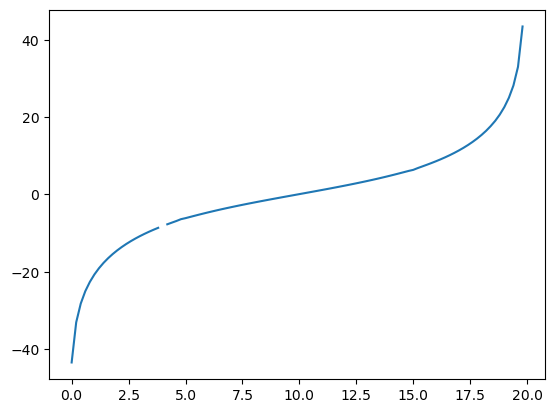

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x176b2dab0>

In [52]:
@time p=StarMES.linScan3D( msh, V, [0,-9.9,0], [0,9.9,0], 100 )
using PyPlot
PyPlot.plot(p[:,1],p[:,2])

In [ ]:
@time cutmsh,cutV=StarMES.multiCutMesh( msh, V, [(3,-0.1)] )[1]
@time cutmshE,cutE=StarMES.multiCutMesh( msh, mE, [(3,-0.05)] )[1]
extrema( cutV ), extrema( cutE )

In [ ]:
using CairoMakie
fig = Makie.Figure(size = (2000, 1000))

axa = Axis3(fig[1,1], aspect = :data, title = "V [V]", azimuth=90)
axb = Axis3(fig[1,3], aspect = :data, title = "|E| [V/m]", azimuth=90)

Colorbar(fig[1, 2], limits = (minimum(cutV),maximum(cutV)), colormap = :viridis, flipaxis = false)
Colorbar(fig[1, 4], limits = (minimum(cutE),maximum(cutE)), colormap = :viridis, flipaxis = false)

mesh!(axa, cutmsh["x"], cutmsh["v"], color = (cutV[:]), shading = NoShading)
StarMES.mesh_contour!(
    axa,
    cutmsh["x"],
    cutmsh["v"],
    cutV;
    levels=range(minimum(cutV), maximum(cutV), length=51),
    color=:black,
    linewidth=1
)

mesh!(axb, cutmshE["x"], cutmshE["v"], color = log.(cutE[:]), shading = NoShading)
#=
StarMES.mesh_contour!(
    axb,
    cutmshE["x"],
    cutmshE["v"],
    cutE;
    levels=range(minimum(cutE), maximum(cutE), length=51),
    color=:black,
    linewidth=1
)
=#

fig

In [ ]:
fig = Makie.Figure()
axa = Axis3(fig[1,1], aspect=:data, title="E [V/m]", azimuth=90)

mesh!(axa, cutmshE["x"], cutmshE["v"], color=log.(cutE[:]), shading=NoShading)

StarMES.mesh_contour!(
    axa,
    cutmshE["x"],
    cutmshE["v"],
    cutE;
    levels=range(minimum(log.(cutE[:])), maximum(log.(cutE[:])), length=51),
    color=:black,
    linewidth=1
)

fig

In [ ]:
@time cutmsh,cutV=StarMES.multiCutMesh( msh, V, [(2,0)] )[1]
@time cutmshE,cutE=StarMES.multiCutMesh( msh, mE, [(2,0)] )[1]
extrema( cutV ), extrema( cutE )

In [ ]:
using CairoMakie
fig = Makie.Figure(size = (2000, 1000))

axa = Axis3(fig[1,1], aspect = :data, title = "V [V]", azimuth=90)
axb = Axis3(fig[1,3], aspect = :data, title = "|E| [V/m]", azimuth=90)

Colorbar(fig[1, 2], limits = (minimum(cutV),maximum(cutV)), colormap = :viridis, flipaxis = false)
Colorbar(fig[1, 4], limits = (minimum(cutE),maximum(cutE)), colormap = :viridis, flipaxis = false)

mesh!(axa, cutmsh["x"], cutmsh["v"], color = (cutV[:]), shading = NoShading)
#=
StarMES.mesh_contour!(
    axa,
    cutmsh["x"],
    cutmsh["v"],
    cutV;
    levels=range(minimum(cutV), maximum(cutV), length=51),
    color=:black,
    linewidth=1
)
=#

mesh!(axb, cutmshE["x"], cutmshE["v"], color = log.(cutE[:]), shading = NoShading)
#=
StarMES.mesh_contour!(
    axb,
    cutmshE["x"],
    cutmshE["v"],
    cutE;
    levels=range(minimum(log.(cutE[:])), maximum(log.(cutE[:])), length=51),
    color=:black,
    linewidth=1
)
=#

fig


In [ ]:
@time cutmsh4,cutV4=StarMES.multiCutMesh( msh, V, [(3,-4)] )[1]
@time cutmsh6,cutV6=StarMES.multiCutMesh( msh, V, [(3,-6)] )[1]
extrema( cutV4 ), extrema( cutV6 )

In [ ]:
using CairoMakie
fig = Makie.Figure(size = (2000, 1000))

axa = Axis3(fig[1,1], aspect = :data, title = "V [V]", azimuth=90)
axb = Axis3(fig[1,3], aspect = :data, title = "V [V]", azimuth=90)

vrange = (minimum(cutV4),maximum(cutV4))

Colorbar(fig[1, 2], limits = vrange, colormap = :viridis, flipaxis = false)
Colorbar(fig[1, 4], limits = vrange, colormap = :viridis, flipaxis = false)

mesh!(axa, cutmsh4["x"], cutmsh4["v"], color = (cutV4[:]), colorrange = vrange, shading = NoShading)

StarMES.mesh_contour!(
    axa,
    cutmsh4["x"],
    cutmsh4["v"],
    cutV4;
    levels=range(minimum(cutV4), maximum(cutV4), length=51),
    color=:black,
    linewidth=1
)


mesh!(axb, cutmsh6["x"], cutmsh6["v"], color = (cutV6[:]), colorrange = vrange, shading = NoShading)

StarMES.mesh_contour!(
    axb,
    cutmsh6["x"],
    cutmsh6["v"],
    cutV6;
    levels=range(minimum(cutV4), maximum(cutV4),length=51),
    color=:black,
    linewidth=1
)

fig

In [ ]:
@time cuts=StarMES.multiCutMesh( msh, V, [(1,0),(2,0)] )
cutmshx,cutVx = cuts[1]
cutmshy,cutVy = cuts[2]
extrema( cutVx )

In [ ]:
length(cuts)


In [ ]:
using GLMakie
GLMakie.activate!()

fig = Makie.Figure()
axa = Axis3(fig[1,1], aspect=:data, title="V [V]",     azimuth = 0, elevation = pi/2)

vrange = (minimum(cutVx),maximum(cutVx))

#mesh!(axa, cutmshx["x"], cutmshx["v"], color=(cutVx[:]), colorrange = vrange, shading=NoShading)

#mesh!(axa, cutmshy["x"], cutmshy["v"], color=(cutVy[:]), colorrange = vrange, shading=NoShading)

StarMES.mesh_contour!(
    axa,
    cutmshx["x"],
    cutmshx["v"],
    cutVx;
    levels=range(minimum(cutVx), maximum(cutVx), length=11),
    color=:black,
    linewidth=1
)

fig

In [ ]:
extrema(cutmsh["x"][:,3])

In [ ]:
using GLMakie
GLMakie.activate!()

fig = WGLMakie.Figure(size=(1000,800))
axa = Axis3(fig[1,1], aspect=:data)

mesh!(axa, cutmshx["x"], cutmshx["v"], color=cutVx[:], shading=NoShading)

fig